# Applied Math 10: Computing for Science and Engineering

## Lab 08 : Data Fitting

**Fall 2020**<br/>

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Fitting our first set of data points

![](linear.png)

**Discussion:** Why do we want to fit functions anyway?

### 1.1 Load the data

**Exercice:**
- Let's import the set of (x, y) points by loading the following two data files: `data/AM10_L08_1_x.txt` and `data/AM10_L08_1_y.txt` in variables `x_1` and `y_1` respectively.
- Check to shape of the two arrays. 
- Plot the two arrays. 

**Discussion**: Describe what you see in terms of the shape of the data. What kind of function would make a good fit? 

In [2]:
# Load the data 
x_1=np.loadtxt('AM10_L08_1_x.txt')
y_1=np.loadtxt('AM10_L08_1_y.txt')

In [3]:
# your code here


50 50 (50,) (50,)


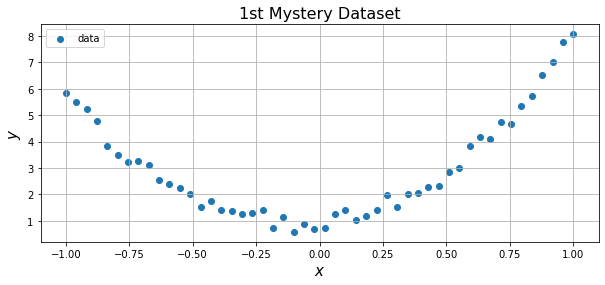

In [4]:
print(len(x_1), len(y_1), x_1.shape, y_1.shape)

# Plot the data
fonts = 15
fig = plt.figure(figsize=(10,4))
plt.xlabel(r'$x$', fontsize=fonts)
plt.ylabel(r'$y$', fontsize=fonts)
plt.title(f'1st Mystery Dataset', fontsize=fonts+1)
plt.scatter(x_1, y_1, label='data');
plt.grid();
plt.legend();
plt.show();

### 1.2  Let's Fit a Polynomial

It does not seem that we can fit this set of points with a line. So let's try a second degree polynomial, which, as we know, is described by the formula:<BR><BR>
$$ {\rm P(x)} = a\cdot{x^2}+b\cdot{x}+c
$$ 
<br>

In [5]:
# Let's define a 2nd degree polynomial
def poly2(x,a,b,c):
    return a*(x**2)+b*x+c

**Exercice:**
- Choose a range of $x$ points and 3 parameters and plot this `poly2` function. 

In [6]:
# your code here


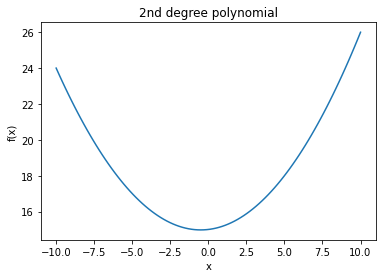

In [7]:
# Let's try it out
x = np.linspace(-10,10, 100)
a, b, c = 0.1, 0.1, 15.
y = poly2(x, a, b, c)
plt.title('2nd degree polynomial')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x,y);

### Problem 1: Plot a 4th degree polynomial

Using the previous exercise as an example, define a function that calculates a 4th degree polynomial and plot it for a range of your choice.

In [8]:
# your code here


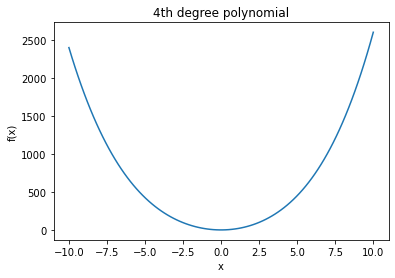

In [9]:
# %load solutions/exercise1.py
## Define 4th order polynolmial 
def poly4(x,a,b,c,d,e):
    return a*(x**4) + b*(x**3) + c*(x**2) + d*x + e

x = np.linspace(-10,10, 100)
a,b,c,d,e = 0.1, 0.1, 15., 0.1, 0.1

y = poly4(x, a, b, c, d, e)
plt.title('4th degree polynomial')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x,y);

### Now, for the actual fitting!

**Exercise:** Let's try to fit a 2nd degree polynomial in our mystery dataset. We will guess the parameters

RMSE=[1.39122717]


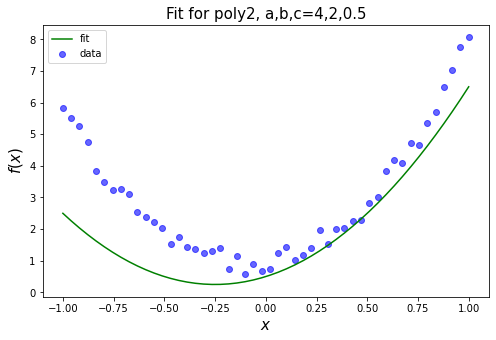

In [17]:
# guess the parameters
a, b, c = 4, 2, 0.5
ffit = poly2(x_1, a, b, c) 

# calculate the rmse
Nd = np.shape(x_1)
ovrNd = (1.0/np.sqrt(Nd))
rmsefit = ovrNd*np.sqrt(np.sum((ffit-y_1)**2))

title = f'Fit for poly2, a,b,c={a},{b},{c}'
print(f'RMSE={rmsefit}')
plt.figure(figsize=(8,5))
plt.title(title, fontsize=fonts)
plt.scatter(x_1,y_1, facecolor = 'blue', alpha = 0.6, label='data')

plt.plot(x_1,ffit,'g', label='fit') 
plt.xlabel(r'$x$', fontsize=fonts)
plt.ylabel(r'$f(x)$', fontsize=fonts)
plt.legend()
plt.show();

#### Now, we will use `scipy`'s `curve_fit`.

In [11]:
def fit_and_plot_func(func, x, y, title):
    """
       Fit and plot a polynomial. 
       Arguments: poly function, x data, y data
       Returns: the plot of the fit
        """
    
    # first find the optimal values for the parameters (coefficients) 
    # so that the sum of the squared residuals of f(x, *popt) - y is minimized.
    popt, _ = curve_fit(func, x, y)
    num_vars = len(popt)
    print(f'Number of variables={num_vars}')
    print(f'{popt}')
    # find the fit for the function
    ffit=func(x,*popt) 

    # calculate the rmse
    Nd=np.shape(x)
    ovrNd=(1.0/np.sqrt(Nd))
    rmsefit=ovrNd*np.sqrt(np.sum((ffit-y)**2))

    print(f'RMSE={rmsefit}')
    plt.figure(figsize=(8,5))
    plt.title(title, fontsize=fonts)
    plt.scatter(x,y, facecolor = 'blue', alpha = 0.6, label='data')
    
    plt.plot(x,ffit,'g', label='fit') 
    plt.xlabel(r'$x$', fontsize=fonts)
    plt.ylabel(r'$f(x)$', fontsize=fonts)
    plt.legend()
    plt.show();

Number of variables=3
[5.9833939  1.01550695 0.89360353]
RMSE=[0.22535449]


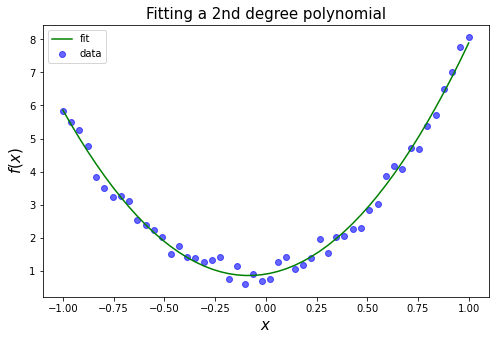

In [12]:
# fit and plot our actual data, xdata, and ydata
fit_and_plot_func(poly2, x_1, y_1, 'Fitting a 2nd degree polynomial') 

### Functions with variable number of arguments.

Hardcoding the definitions of the polynomials for the 2nd and 4th degree polynomials was not so bad. What if, though, we wanted to define a function for creating a 6th, or 7th, or 10th degree polynomial? We would have to write a separate function for each one. **Why?**

A $n$th degree polynomial is described by the formula:
$$ {\rm P_n(x)} = \sum_{k=0}^n a_k\cdot{x^k}
$$
Where $a_n$ are the coefficients. <br>

```python    
    def poly(x:np.array, *coeffs):
        """Define a polynomial of variable degree. 
           Arguments: 
           x = array of data points, 
           *coeffs = ordered set of coefficients corresponding to polynomial exponents 
                     in order of descending powers
           Returns: an array of the number values of the polynomial on the data points
        """
  
       p = 0
       # we reverse the coeff array to match the expression of the polynomial 
       # a*x^n + b*x^(n-1) + ...
       coeffs = <reverse_the_array>
        
       #loop though the arguments
       for i, value in enumerate(coeffs): 
           p = <do_something>
       
       return p
```

#### First some useful piece of code: how to iterate through an array

In [13]:
# our array
coeffs = [2.,0.5,7.,3.]
for i, value in enumerate(coeffs):
    print(f'{i}, value={value}')

0, value=2.0
1, value=0.5
2, value=7.0
3, value=3.0


#### How to reverse an array and why you might need to do this.

We are doing this to match the coefficients's **index** in the `coeff` array with the **exponent** to which their respective variable is raised in the polynomial. 
<BR>
So, if we have the following polynomial:
<BR>
$$ {\rm P(x)} = a\cdot{x^2}+b\cdot{x}+c
$$ 
<BR>
and the following coefficient array: `coeff` = array[a, b, c]<BR><BR>
`coeff[0]` = $a$ so $a$'s **index**=$0$, BUT $a$'s **exponent**=$2$ because we have $a\cdot{x^2}$<BR><BR>
If `coeff` = array[c, a, b] then the indexes match the exponents.
    
There are multiple ways to write the `poly` function and you might find one that does not require you to reverse the array. It's fine as long as it gives us the right result! <BR><BR>
In the example below, $a=2., b=0.5, c=7.0, d=3.$

In [14]:
coeffs = [2.,0.5,7.,3.]
print(f'array before reversing:{coeffs}')
coeffs = coeffs[::-1]
print(f'array after reversing:{coeffs}')

array before reversing:[2.0, 0.5, 7.0, 3.0]
array after reversing:[3.0, 7.0, 0.5, 2.0]


*For more on functions read the [scipy notes](https://scipy-lectures.org/intro/language/functions.html)*.

### Problem 2: Create a function that calculates a polynomial with an arbitrary number of arguments
- Write the Python function `poly()`, defined above, for an arbitrary polynomial, with arguments 

1. x = the datapoints and 

2. \*coeffs = the coefficients. 

- Then, create a function named `poly2()` that uses `poly()` to create a 2nd degree polynomial. 
- Finally, plot the 2nd degree polynomial.

In [15]:
# your code here


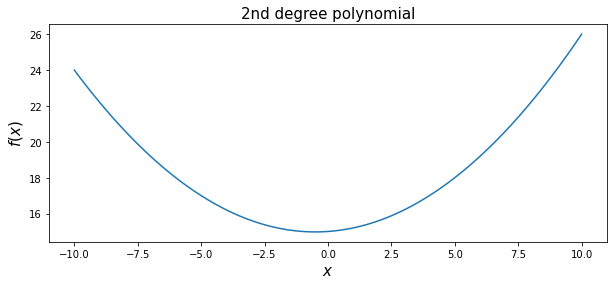

In [16]:
# %load solutions/exercise2.py
def poly(x:np.array, *coeffs):
    """Defines a polynomial of variable degree. 
       Arguments: x = array of data points, 
       *coeffs = ordered set of coefficients corresponding to polynomial exponents 
                 in order of descending powers
       Returns: an array of the number values of the polynomial on the data points
    """
    
    p = np.zeros(len(x))
    # we reverse the coeff array to match the a*x^n + b*x^(n-1) + ... + constant*x^0
    coeffs = coeffs[::-1]
    for degree, coeff in enumerate(coeffs):
        p += coeff * x**degree
    return p

# Define the 2nd degree using the generic function
def poly2(x,a,b,c):
    return poly(x,a,b,c)

x = np.linspace(-10,10, 100)
a, b, c = 0.1, 0.1, 15.
fig = plt.figure(figsize=(10,4))
plt.xlabel(r'$x$', fontsize=fonts)
plt.ylabel(r'$f(x)$', fontsize=fonts)
plt.title('2nd degree polynomial', fontsize=fonts)
plt.plot(x, poly2(x, a, b, c));
plt.show();
